In [1]:
# EJERCICIO 1 - Realiza una exploración del conjunto de datos (heart_disease.csv)
# utilizando métodos de la librería pandas para cargar, filtrar y listar tablas de datos

# Se importa la biblioteca Pandas, necesaria para trabajar con DataFrames (datos en forma de tablas)
# y poder usar funciones como read_csv(), info(), describe(), etc.
import pandas as pd

# SE sube el archivo heart_disease.csv a Colab

# Se carga el archivo heart_disease.csv en un DataFrame de Pandas, para poder
# procesar sus datos de forma estructurada.
df = pd.read_csv('/content/heart_disease.csv')


# SE muestran las primeras filas del DataFrame para obtener una visión rápida
# de cómo son las columnas y los valores iniciales del conjunto de datos.
print("Primeras filas del dataset:")
print(df.head())


# Se muestra información estructural del DataFrame: número de filas y columnas,
# tipos de datos y cantidad de valores no nulos en cada variable.
print("--------------------------------------------------------- ")
print("Información estructural del DataFrame:")
df.info()



# Se muestran estadísticas descriptivas de las variables numéricas
print("--------------------------------------------------------- ")
print("Estadísticas descriptivas:")
print(df.describe())







Primeras filas del dataset:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0     

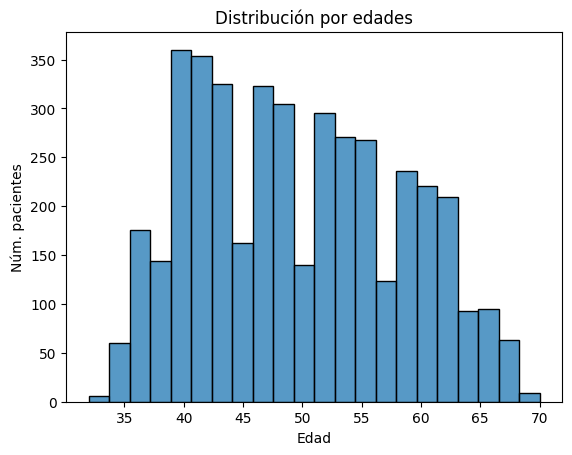

----------------------------------------------------------------------------------


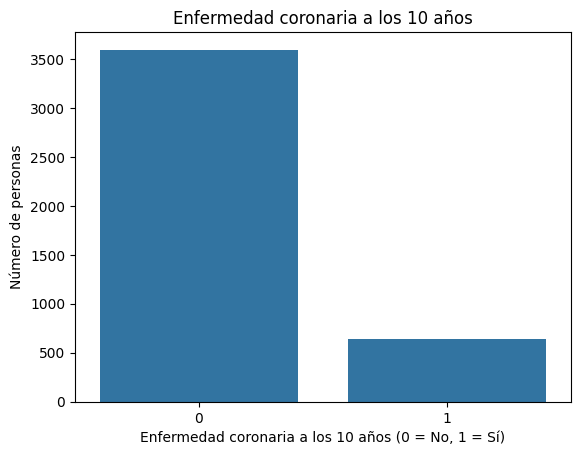

In [2]:
# EJERCICO 2: Prepara una o más funciones que permitan realizar una exploración
# visual de los datos más relevantes utilizando las librerías de python de tu elección.

# Se seleccionan "edad" y "Enfermedad coronaria a los 10 años" como datos para
# este ejercicio por su relevancia. Edad es una variable continua de relevancia
# evidente en el contexto de la enfermedad cardiovascular y "Enfermedad coronaria
# a los 10 años" es el objetivo a predecir, y es binaria, lo que permite utilizar
# un segundo tipo de gráfico diferente al de la edad.

# Se importan las librerías necesarias para realizar la exploración visual.
import matplotlib.pyplot as plt
import seaborn as sns

# APARTADO A) Exploración visual de la variable "edad" (AGE)
# Se utiliza un histograma para representar la variable "edad" porque se trata de
# una variable numérica continua. El histograma permite visualizar fácilmente la
# distribución por edades en el DataFrame.

# Se crea el histograma para la variable "age" por medio de seaborn
sns.histplot(df['age'])
# Se pone título al gráfico
plt.title("Distribución por edades")
# Se establecen las unidades de los ejes
plt.xlabel("Edad")
plt.ylabel("Núm. pacientes")
#Se muestra el gráfico
plt.show()

# APARTADO B) Exploración visual de la variable "Enfermedad coronaria a los 10 años" (TenYearCHD)
# Se trata de una variable binaria (0 = no, 1 = sí ), por lo que la forma seleccionada
# de visualizarla es mediante un gráfico de barras.
print("----------------------------------------------------------------------------------")

# Se crea el gráfico de barras para la variable "TenYearCHD" por medio de seaborn
sns.countplot(x=df['TenYearCHD'])

# Se pone título al gráfico
plt.title("Enfermedad coronaria a los 10 años")

# Etiquetas de los ejes
plt.xlabel("Enfermedad coronaria a los 10 años (0 = No, 1 = Sí)")
plt.ylabel("Número de personas")

#Se muestra el gráfico
plt.show()


In [3]:
# EJERCICIO 3: Si lo estimas necesario, ejecuta métodos de imputación y normalización de datos
# explicando brevemente tus decisiones.

# Se revisa la existencia de valores nulos en el DataFrame
print("Valores nulos por columna:")
print(df.isnull().sum())

# Si el porcentaje de valores perdidos es pequeño, se recomiendan
# métodos simples de imputación (media, mediana o moda). A continuación, se aplican
# imputaciones sólo en las columnas que contienen valores faltantes.
# Se opta por la mediana, ya que funciona bien frente a valores extremos,
# característica relevante en variables clínicas que pueden presentar distribuciones sesgadas.
# La variable glucose presenta un número mayor de valores perdidos (alrededor del 10% del total).
# Dado que se trata de una variable numérica clínicamente relevante, se opta igualmente
# por imputar la mediana en lugar de eliminar la columna.

# Se muestra la mediana en las columnas con valores nulos
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
print("----------------------------------------------------------------------------------")
print("Medianas de las columnas numéricas con valores nulos:")
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        print(f"{col}: {df[col].median()}")

# En las variables cigsPerDay y BPMeds la mediana es 0 porque la mayoría de participantes no fuman
# o no reciben medicación antihipertensiva. esto confirma lo idóneo de usar la meidana
# frente a la media.

# No es necesario realizar distinción con las variables categóricas (education, BPMeds...),
# ya que están recogidas como valores numéricos (0/1; education de 1 a 4).
# El modelo seleccionado (Random Forest) admite correctamente este formato.

# Se imputan los valores nulos utilizando la mediana de cada columna
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("--------------------------------------------------------------------------")
print("Valores nulos tras la imputación:")
print(df.isnull().sum())

# No se realiza normalización porque el modelo que se utilizará (Random Forest)
# no lo hace necesario.






Valores nulos por columna:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
----------------------------------------------------------------------------------
Medianas de las columnas numéricas con valores nulos:
education: 2.0
cigsPerDay: 0.0
BPMeds: 0.0
totChol: 234.0
BMI: 25.4
heartRate: 75.0
glucose: 78.0
--------------------------------------------------------------------------
Valores nulos tras la imputación:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP            

In [4]:
# Se reinicia el DataFrame para que el proceso completo del Ejercicio 4
# quede reflejado correctamente en el PDF.
df = pd.read_csv('/content/heart_disease.csv')

# Se aplica de nuevo la imputación básica (Ejercicio 3) antes de la selección de características.
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# EJERCICIO 4: Realiza un análisis básico de selección de características
# siguiendo técnicas vistas en el módulo para obtener una submuestra depurada.

# A) FILTRO DE ALTA CORRELACIÓN
corr_matrix = df.corr()

# Se muestra una matriz parcial para no saturar el PDF
print("-----------------------------------------------------------")
print("Matriz de correlación (primeras columnas):")
print(corr_matrix.iloc[:5, :5])

# Análisis de correlación completa con umbral 0.6
# Se decide que correlaciones >0.6 indican relación relevante; posible redundancia)
umbral = 0.6
correlaciones_altas = []

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2:
            valor = corr_matrix.loc[col1, col2]
            if abs(valor) > umbral:
                correlaciones_altas.append((col1, col2, valor))

print("-----------------------------------------------------------")
print(f"Pares de columnas con correlación alta (> {umbral}):")
for col1, col2, valor in correlaciones_altas:
    print(f"{col1}  <-->  {col2}   (corr = {valor:.3f})")

# A partir del análisis, se decide eliminar dos variables consideradas redundantes
# (Se consideran redundantes en base a criterios clínicos propios)
# "diabetes" o "diabético": variable binaria derivada directamente de los valores de glucosa.
# "prevalentHyp" o "hipertenso": etiqueta diagnóstica basada fundamentalmente en la tensión arterial.
# Lo relevante es la cifra, y no que se haya establecido la etiqueta diagnóstica.

columnas_a_eliminar = ['diabetes', 'prevalentHyp']

print("-----------------------------------------------------------")
print("Columnas eliminadas por criterios clínicos, en base a correlación:")
print(columnas_a_eliminar)

df = df.drop(columns=columnas_a_eliminar)

# B) FILTRO DE BAJA VARIANZA
print("-----------------------------------------------------------")
print("Varianza de las columnas numéricas:")
print(df.var())

# Se deciden eliminar variables con varianza muy baja, tanto por el valor
# como por criterio clínico
columnas_var_baja = ['prevalentStroke', 'BPMeds']
print("-----------------------------------------------------------")
print("Columnas eliminadas por baja varianza:")
print(columnas_var_baja)

df = df.drop(columns=columnas_var_baja)

# RESULTADO FINAL
print("-----------------------------------------------------------")
print("Columnas finales seleccionadas:")
print(df.columns.tolist())
print("Número de columnas seleccionadas:", len(df.columns))


-----------------------------------------------------------
Matriz de correlación (primeras columnas):
                   male       age  education  currentSmoker  cigsPerDay
male           1.000000 -0.028979   0.017205       0.197596    0.315630
age           -0.028979  1.000000  -0.163547      -0.213748   -0.191847
education      0.017205 -0.163547   1.000000       0.018273    0.007618
currentSmoker  0.197596 -0.213748   0.018273       1.000000    0.760239
cigsPerDay     0.315630 -0.191847   0.007618       0.760239    1.000000
-----------------------------------------------------------
Pares de columnas con correlación alta (> 0.6):
currentSmoker  <-->  cigsPerDay   (corr = 0.760)
cigsPerDay  <-->  currentSmoker   (corr = 0.760)
prevalentHyp  <-->  sysBP   (corr = 0.697)
prevalentHyp  <-->  diaBP   (corr = 0.616)
diabetes  <-->  glucose   (corr = 0.606)
sysBP  <-->  prevalentHyp   (corr = 0.697)
sysBP  <-->  diaBP   (corr = 0.784)
diaBP  <-->  prevalentHyp   (corr = 0.616)
diaBP  <--

In [9]:
# EJERCICIO 5: Partiendo de la submuestra final , genera los grupos de entrenamiento
# y validación e imprime por pantalla alguna característica del mismo.

from sklearn.model_selection import train_test_split

# La variable objetivo (lo que se quiere predecir) es la ocurrencia de un
# evento coronoario a los 10 años (TenYearCHD)

# Se separan las características (X) y la variable objetivo (y)
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

print("Dimensiones de la submuestra:")
print("X:", X.shape)
print("y:", y.shape)

# División del dataset en entrenamiento y validación. SE decide que la proporción
# sea 20-80
# Se utiliza stratify=y para mantener la proporción de clases
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("-----------------------------------------------------------")
print("Dimensiones del conjunto de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("-----------------------------------------------------------")
print("Dimensiones del conjunto de validación:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

# Proporción de muestras en cada conjunto (en porcentaje)
total_muestras = len(X)

prop_train = len(X_train) / total_muestras * 100
prop_val = len(X_val) / total_muestras * 100

print("-----------------------------------------------------------")
print("Proporción de muestras en cada conjunto:")
print(f"Entrenamiento: {prop_train:.4f} %")
print(f"Validación: {prop_val:.4f} %")

# Comprobación de distribución similar de la variable objetivo en los conjuntos
# de entrenamiento y de test

print("-----------------------------------------------------------")
print("Distribución de la variable objetivo en el conjunto de entrenamiento:")
print(y_train.value_counts())

print("-----------------------------------------------------------")
print("Distribución de la variable objetivo en el conjunto de validación:")
print(y_val.value_counts())

print("-----------------------------------------------------------")
print("Distribución relativa de la variable objetivo (tanto por 1) - Entrenamiento:")
dist_train = y_train.value_counts(normalize=True)
print(dist_train)

print("-----------------------------------------------------------")
print("Distribución relativa de la variable objetivo (tanto por 1) - Validación:")
dist_val = y_val.value_counts(normalize=True)
print(dist_val)

print("-----------------------------------------------------------")
print("Comparación de distribuciones:")
print("La distribución de la variable objetivo es similar en los conjuntos de entrenamiento y validación")


Dimensiones de la submuestra:
X: (4238, 11)
y: (4238,)
-----------------------------------------------------------
Dimensiones del conjunto de entrenamiento:
X_train: (3390, 11)
y_train: (3390,)
-----------------------------------------------------------
Dimensiones del conjunto de validación:
X_val: (848, 11)
y_val: (848,)
-----------------------------------------------------------
Proporción de muestras en cada conjunto:
Entrenamiento: 79.9906 %
Validación: 20.0094 %
-----------------------------------------------------------
Distribución de la variable objetivo en el conjunto de entrenamiento:
TenYearCHD
0    2875
1     515
Name: count, dtype: int64
-----------------------------------------------------------
Distribución de la variable objetivo en el conjunto de validación:
TenYearCHD
0    719
1    129
Name: count, dtype: int64
-----------------------------------------------------------
Distribución relativa de la variable objetivo (tanto por 1) - Entrenamiento:
TenYearCHD
0    0.84